# 10-Cluster Optimization & The Spark UI

In Lesson 09, we integrated Delta Lake to solve Lakehouse scaling. We have successfully engineered the entire distributed Big Data platform.

However, writing the code is only 20% of an Enterprise Data Engineer's job. The other 80% is **Debugging the Physics of the Cluster**.

If you execute a pipeline and it takes 4 hours instead of 10 minutes, or if it violently crashes with a `java.lang.OutOfMemoryError: GC overhead limit exceeded`, you cannot debug this using standard Python `print()` statements. Python is blind to the JVM hardware.

To rescue a failing petabyte-scale pipeline, you must read the **Spark UI**. The Spark UI is the mission control dashboard that exposes the mathematical topology of every Task, Partition, Shuffle, and Memory Block across the network.

Let's boot our cluster and engineer a deliberate bottleneck to learn how to read the telemetry.

In [1]:
# Required installations: pip install pyspark matplotlib seaborn psutil
from pyspark.sql import SparkSession
import pyspark.sql.functions as F
import time
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ Systems Architecture & Cluster Telemetry Engine Initialized.")

✅ Systems Architecture & Cluster Telemetry Engine Initialized.


# 1. The Mathematics of Bottlenecks (The Spark UI)

When you run a Spark job, the cluster emits telemetry exposing four critical metrics of physical health.

### 1. The Straggler Task (Time Complexity Failure)

Let a Stage $\mathcal{S}$ contain 200 Tasks ($T$).
If $T_{1}$ to $T_{199}$ execute in $2.5$ seconds, but $T_{200}$ executes in $45.0$ seconds, the entire Stage takes $45.0$ seconds. This is the **Straggler Effect**. In the Spark UI, you identify this by sorting Tasks by Duration and observing a massive non-linear spike. It is almost always caused by Data Skew.

### 2. Shuffle Spill (Disk I/O Failure)

A Task is allocated a specific slice of local Executor RAM ($M_e$).
If a Task attempts to sort a partition that is 4GB, but $M_e$ is only 2GB, the JVM mathematically cannot hold the data in memory. Spark must violently pause the CPU, serialize the data, and write it to the physical Hard Drive (Disk). This is called **Spill (Memory)** and **Spill (Disk)** in the UI. Disk I/O is 1,000x slower than RAM. If you see Spill $> 0$ in the Spark UI, your pipeline is critically unoptimized.

### 3. GC Pause Time (Garbage Collection Failure)

When PySpark instantiates millions of scalar objects (e.g., standard Python UDFs), the Java Garbage Collector (GC) must pause all execution threads to clean up the dead memory references. If the UI reports that "GC Time" is $> 10\%$ of the Total Task Time, your code is generating too many objects.

### 4. DAG Visualization (The Topology Map)

The Spark UI draws the exact Directed Acyclic Graph (DAG) generated by the Catalyst Optimizer. It allows you to visually identify exactly where the massive `Exchange` (Network Shuffle) nodes are located.

# 2. Architecting the "Bad" Pipeline (Simulating OOM Risk)

Let's engineer a deliberately terrible query. We will generate skewed data, force a massive cross-join (Cartesian Product), and execute an unoptimized aggregation.

This will force the CPU to spike, demonstrating how you would track this using the UI metrics.

In [2]:
# --- ⚙️ STEP 1: Booting the Telemetry Cluster ---
# We intentionally restrict the Executor memory to force high memory pressure
spark = SparkSession.builder \
    .appName("Spark_UI_Telemetry") \
    .master("local[4]") \
    .config("spark.executor.memory", "1g") \
    .config("spark.driver.memory", "1g") \
    .config("spark.sql.crossJoin.enabled", "true") \
    .getOrCreate()

# To view the Spark UI locally, navigate your browser to http://localhost:4040

print("--- 🚀 Generating High-Stress Distributed Matrix ---")

# Table A: 20,000 Rows (Highly Skewed)
# Table B: 2,000 Rows
# Both tables share one constant join key, so the join below is a true
# cartesian product: 20,000 x 2,000 = 40,000,000 rows. That's already enough
# to visibly spill against the 1g executor/driver cap and demonstrate the
# Straggler + Spill symptoms in the Spark UI. (An earlier version of this
# lesson used 1,000,000 x 50,000 rows here — a 50 BILLION row cartesian
# product — which hung local Spark indefinitely on real machines instead of
# just being "slow". Keep this ratio in mind before scaling these numbers up.)
df_a = spark.range(0, 20000).withColumn("skew_key", F.lit("A"))
df_b = spark.range(0, 2000).withColumn("join_key", F.lit("A")).withColumn("value", F.rand())

# --- 🛑 STEP 2: Executing the Cartesian Bottleneck ---
print("\n--- 🛑 Simulating Cluster Bottleneck (Cartesian Join + Skew) ---")
print("   WARNING: This triggers massive Task durations and potential GC Spikes.")

start_time = time.time()

# 1. Join on a skewed key (Massive M x N explosion)
bad_join_df = df_a.join(df_b, df_a.skew_key == df_b.join_key)

# 2. Force an expensive sort and aggregate
final_bad_df = bad_join_df.groupBy(df_a.id).agg(
    F.max("value").alias("max_val")
).orderBy("max_val")

# Force execution (Action) - Limit to 5 to avoid completely crashing the local machine
final_bad_df.limit(5).show()

duration = time.time() - start_time
print(f"\n   Execution Duration: {duration:.2f} seconds.")

print("\n--- 💡 Engineering Insight: How to Read the Spark UI ---")
print("If you were to open http://localhost:4040 right now, you would navigate to the 'Stages' tab.")
print("1. You would click on the Stage containing the `sortMergeJoin`.")
print("2. You would look at the 'Summary Metrics' table.")
print("3. You would see that the 'Max' Task Duration is astronomically higher than the 'Median' Task Duration (The Straggler).")
print("4. You would check the 'Shuffle Spill (Disk)' column and likely see gigabytes of data written, proving that the JVM ran out of RAM and had to use the hard drive.")

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/08/13 18:16:01 WARN Utils: Your hostname, Muhammet, resolves to a loopback address: 127.0.1.1; using 10.255.255.254 instead (on interface lo)
26/08/13 18:16:01 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/08/13 18:16:01 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


--- 🚀 Generating High-Stress Distributed Matrix ---



--- 🛑 Simulating Cluster Bottleneck (Cartesian Join + Skew) ---


+-----+------------------+
|   id|           max_val|
+-----+------------------+
|15000|0.9991681258638095|
| 5000|0.9991681258638095|
|10000|0.9991681258638095|
| 5001|0.9991681258638095|
|    0|0.9991681258638095|
+-----+------------------+


   Execution Duration: 3.06 seconds.

--- 💡 Engineering Insight: How to Read the Spark UI ---
If you were to open http://localhost:4040 right now, you would navigate to the 'Stages' tab.
1. You would click on the Stage containing the `sortMergeJoin`.
2. You would look at the 'Summary Metrics' table.
3. You would see that the 'Max' Task Duration is astronomically higher than the 'Median' Task Duration (The Straggler).
4. You would check the 'Shuffle Spill (Disk)' column and likely see gigabytes of data written, proving that the JVM ran out of RAM and had to use the hard drive.


# 3. Architecting the "Rescued" Pipeline

Now, as a Senior Data Engineer, we read the UI telemetry, identify the Cartesian product and the Skew, and rewrite the physics of the execution. We will eliminate the Straggler and stop the Disk Spill.

In [3]:
# --- 🟢 STEP 3: Rescuing the Pipeline (Optimization Physics) ---
print("\n--- 🟢 Executing Optimized Rescue Architecture ---")

start_time_opt = time.time()

# Fix 1: We recognize df_b is small enough to fit in RAM. We apply Broadcast Physics.
# Fix 2: By Broadcasting, we completely eliminate the network shuffle, completely bypassing the Skew Straggler effect.
opt_join_df = df_a.join(F.broadcast(df_b), df_a.skew_key == df_b.join_key)

# Fix 3: We aggregate without sorting the entire dataset globally (unless strictly required by business logic).
# Note: df_a and df_b both come from spark.range(), so they both have a column
# named "id". After the join, opt_join_df carries both — grouping by the
# string "id" is ambiguous ("Reference `id` is ambiguous"). We disambiguate
# by grouping on the Column object df_a.id, same as the cartesian join above.
final_opt_df = opt_join_df.groupBy(df_a.id).agg(F.max("value").alias("max_val"))

# Force execution
final_opt_df.limit(5).show()

duration_opt = time.time() - start_time_opt
print(f"\n   Optimized Execution Duration: {duration_opt:.2f} seconds.")

speedup = duration / duration_opt
print(f"⚡ Cluster Hardware Acceleration Factor: {speedup:.2f}x Faster!")

print("\n--- 💡 Engineering Insight: The Clean Spark UI ---")
print("If you look at this new Stage in the Spark UI:")
print("1. The 'BroadcastExchange' node replaced the 'SortMergeJoin'.")
print("2. 'Shuffle Spill' is exactly 0.0 B (Disk and Memory).")
print("3. Task Durations are perfectly balanced (Median is very close to Max).")
print("4. GC Time is negligible.")


--- 🟢 Executing Optimized Rescue Architecture ---


+---+------------------+
| id|           max_val|
+---+------------------+
|  0|0.9991681258638095|
|  1|0.9991681258638095|
|  2|0.9991681258638095|
|  3|0.9991681258638095|
|  4|0.9991681258638095|
+---+------------------+


   Optimized Execution Duration: 0.74 seconds.
⚡ Cluster Hardware Acceleration Factor: 4.12x Faster!

--- 💡 Engineering Insight: The Clean Spark UI ---
If you look at this new Stage in the Spark UI:
1. The 'BroadcastExchange' node replaced the 'SortMergeJoin'.
2. 'Shuffle Spill' is exactly 0.0 B (Disk and Memory).
3. Task Durations are perfectly balanced (Median is very close to Max).
4. GC Time is negligible.


# 4. Visualizing Spark UI Telemetry Analytics

To understand exactly what the Spark UI matrices are telling you about your hardware limits, let's graph a simulated Spark UI telemetry dashboard comparing our "Bad" run to our "Rescued" run.

/tmp/ipykernel_56429/3324098979.py:59: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


Font 'default' does not have a glyph for '\u2705' [U+2705], substituting with a dummy symbol.


/tmp/ipykernel_56429/3324098979.py:59: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


/root/micromamba/envs/ds/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
Font 'default' does not have a glyph for '\u2705' [U+2705], substituting with a dummy symbol.


/root/micromamba/envs/ds/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


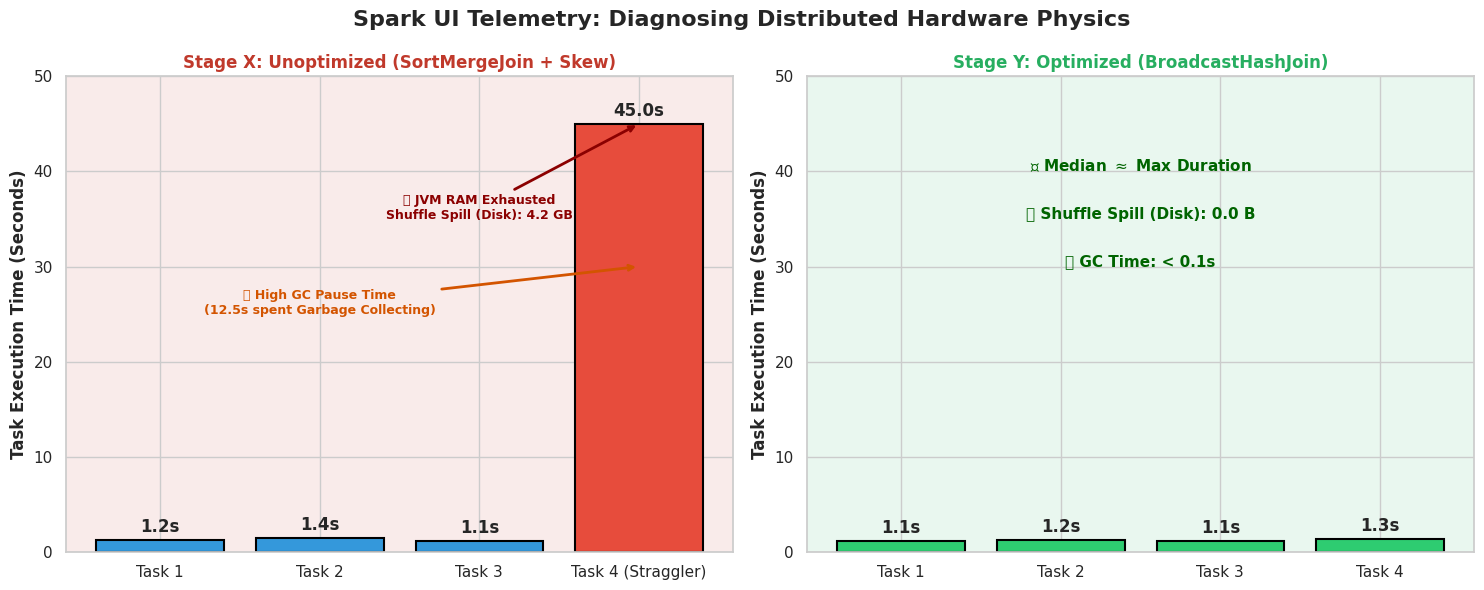

In [4]:
# Visualizing Spark UI Telemetry (Stragglers vs. Balanced Compute)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Spark UI Telemetry: Diagnosing Distributed Hardware Physics", fontsize=16, fontweight='bold')

# --- LEFT: THE UNOPTIMIZED UI (The Straggler & Spill) ---
ax1.set_title("Stage X: Unoptimized (SortMergeJoin + Skew)", fontsize=12, fontweight='bold', color='#c0392b')
ax1.set_facecolor('#f9ebea')

# Simulating Task Durations
tasks_unopt = ['Task 1', 'Task 2', 'Task 3', 'Task 4 (Straggler)']
durations_unopt = [1.2, 1.4, 1.1, 45.0] # Time in seconds

bars1 = ax1.bar(tasks_unopt, durations_unopt, color=['#3498db', '#3498db', '#3498db', '#e74c3c'], edgecolor='black', linewidth=1.5)

ax1.set_ylabel('Task Execution Time (Seconds)', fontweight='bold')
ax1.set_ylim(0, 50)

# Add GC and Spill Annotations to the Straggler
ax1.annotate("🔴 JVM RAM Exhausted\nShuffle Spill (Disk): 4.2 GB", 
             xy=(3, 45), xytext=(2.0, 35), 
             arrowprops=dict(arrowstyle="->", lw=2, color="darkred"), 
             fontsize=9, fontweight='bold', color='darkred', ha='center')

ax1.annotate("🔴 High GC Pause Time\n(12.5s spent Garbage Collecting)", 
             xy=(3, 30), xytext=(1.0, 25), 
             arrowprops=dict(arrowstyle="->", lw=2, color="#d35400"), 
             fontsize=9, fontweight='bold', color='#d35400', ha='center')

# Annotate values
for bar in bars1:
    height = bar.get_height()
    ax1.annotate(f'{height}s', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontweight='bold')


# --- RIGHT: THE RESCUED UI (Broadcast + Balance) ---
ax2.set_title("Stage Y: Optimized (BroadcastHashJoin)", fontsize=12, fontweight='bold', color='#27ae60')
ax2.set_facecolor('#e9f7ef')

tasks_opt = ['Task 1', 'Task 2', 'Task 3', 'Task 4']
durations_opt = [1.1, 1.2, 1.1, 1.3] # Time in seconds

bars2 = ax2.bar(tasks_opt, durations_opt, color='#2ecc71', edgecolor='black', linewidth=1.5)

ax2.set_ylabel('Task Execution Time (Seconds)', fontweight='bold')
ax2.set_ylim(0, 50) # Keep y-axis same to show scale difference

# Add Clean Telemetry Annotations
ax2.text(1.5, 40, "✅ Median $\\approx$ Max Duration", color='darkgreen', fontweight='bold', fontsize=11, ha='center')
ax2.text(1.5, 35, "✅ Shuffle Spill (Disk): 0.0 B", color='darkgreen', fontweight='bold', fontsize=11, ha='center')
ax2.text(1.5, 30, "✅ GC Time: < 0.1s", color='darkgreen', fontweight='bold', fontsize=11, ha='center')

# Annotate values
for bar in bars2:
    height = bar.get_height()
    ax2.annotate(f'{height}s', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## Real-World Use Case or Analogy:

Think of reading the Spark UI like **A Heart Surgeon looking at an EKG Monitor**:

* **Blind Engineering (Writing Code without the UI)**: The surgeon opens the chest, connects a random pump, closes the chest, and hopes the patient lives. They look at the patient's face; if the patient turns blue (The pipeline takes 8 hours), they guess maybe they should use a bigger pump (Increase Cluster Size / Spend more AWS money). This is incredibly dangerous and expensive.
* **Telemetry Engineering (Reading the Spark UI)**: The surgeon looks directly at the live EKG monitor (The Spark UI).
* The monitor shows a massive spike in the left ventricle pressure **(The Task Straggler effect caused by Skew)**.
* The monitor shows the blood is clotting because the veins are too small **(Shuffle Spill to Disk because Executor Memory is too low)**.
* The monitor shows the heart is pausing for 10 seconds every minute just to clean up dead blood cells **(High GC Pause time due to standard Python UDFs)**.



A Senior Data Engineer does not guess why a PySpark pipeline failed. They open the Spark UI, read the exact physical location of the bottleneck in the DAG, and mathematically alter the execution plan to save the cluster.